# HerittageFNS — Bước 2: Huấn Luyện Decision Tree, Random Forest & Trích Xuất Hệ Luật Mờ

Notebook này tiếp nhận dữ liệu mờ đã chuẩn bị từ Bước 1 gồm **3,600 mẫu cân bằng** (600 mẫu/thể loại, được cắt lát 12s từ 1,800 bài hát độc lập):
- **Dữ liệu Crisp**: 7 trục nhãn chữ ngữ nghĩa âm học (được mã hóa thứ bậc Ordinal Encoding).
- **Dữ liệu Continuous**: 27 mức độ liên thuộc mờ liên tục trong khoảng [0, 1].

Quy trình thực hiện:
1. **Nạp dữ liệu & Chia tập**: 80% Huấn luyện (2,880 mẫu), 20% Kiểm thử (720 mẫu) - Stratified Split.
2. **Huấn luyện 4 mô hình**: Decision Tree Crisp, Random Forest Crisp (50 cây), Decision Tree Continuous, Random Forest Continuous (50 cây).
3. **Trích xuất & Tinh lọc hệ luật IF-THEN**: Trích xuất toàn bộ nhánh rẽ từ cây đơn và từ toàn bộ 50 cây của Random Forest; tinh giản điều kiện liên tục, gom nhóm và tính độ tin cậy (Confidence), độ hỗ trợ (Support), tần suất (Frequency).
4. **Lọc Top Luật Vàng (Golden Rules)**: Chọn lọc các luật mạnh nhất cho từng thể loại âm nhạc cổ truyền.
5. **Trực quan hóa**: Vẽ sơ đồ cây quyết định, Feature Importance và Ma trận nhầm lẫn (Confusion Matrix).


In [5]:
import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# Thiết lập giao diện Dark Theme đồng bộ
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d', 'text.color': '#e6edf3',
    'axes.labelcolor': '#e6edf3', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#21262d', 'font.size': 11,
})
print('Setup thư viện và môi trường thành công!')
# Đảm bảo các thư mục đích tồn tại
for d in ['./data/datasets', './data/rules', './data/plots']:
    Path(d).mkdir(parents=True, exist_ok=True)


Setup thư viện và môi trường thành công!


## 1. Nạp Dữ Liệu & Mã Hóa Có Thứ Bậc Âm Học

In [6]:
# Nạp 2 tập dữ liệu mờ đã chuẩn bị
df_crisp = pd.read_csv('./data/datasets/features_fuzzy_crisp.csv')
df_cont  = pd.read_csv('./data/datasets/features_fuzzy_continuous.csv')

print(f'Tập Crisp:      {df_crisp.shape[0]} mẫu × {df_crisp.shape[1]} cột')
print(f'Tập Continuous: {df_cont.shape[0]} mẫu × {df_cont.shape[1]} cột')

# Mã hóa có thứ tự (Ordinal Encoding) cho 7 trục nhãn chữ
crisp_feat_cols = ['Energy', 'Harmony', 'Pitch', 'Spectral', 'Tempo', 'Timbre', 'Vibrato']
ORDINAL_MAPS = {
    'Energy':   {'Rất yếu': 0, 'Yếu': 1, 'Vừa': 2, 'Mạnh': 3, 'Rất mạnh': 4},
    'Harmony':  {'Thấp': 0, 'Trung bình': 1, 'Cao': 2},
    'Pitch':    {'Rất trầm': 0, 'Trầm': 1, 'Trung': 2, 'Cao': 3, 'Rất cao': 4},
    'Spectral': {'Thấp': 0, 'Trung bình': 1, 'Cao': 2},
    'Tempo':    {'Chậm': 0, 'Vừa': 1, 'Nhanh': 2},
    'Timbre':   {'Rất thấp': 0, 'Thấp': 1, 'Trung bình': 2, 'Cao': 3, 'Rất cao': 4},
    'Vibrato':  {'Ít luyến': 0, 'Vừa': 1, 'Nhiều luyến': 2}
}

df_crisp_encoded = df_crisp.copy()
for col in crisp_feat_cols:
    df_crisp_encoded[col] = df_crisp[col].map(ORDINAL_MAPS[col])

# Các cột đặc trưng liên tục (loại bỏ metadata)
meta_cols = ['sample_idx', 'label', 'audio_path', 'segment_id']
cont_feat_cols = [c for c in df_cont.columns if c not in meta_cols]

# Chuẩn bị X, y
X_crisp = df_crisp_encoded[crisp_feat_cols].values
y_crisp = df_crisp['label'].values

X_cont  = df_cont[cont_feat_cols].values
y_cont  = df_cont['label'].values

class_names = sorted(list(set(y_crisp)))

# Phân chia 80% Train, 20% Test (Stratified)
X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_crisp, y_crisp, test_size=0.20, random_state=42, stratify=y_crisp
)

X_cnt_train, X_cnt_test, y_cnt_train, y_cnt_test = train_test_split(
    X_cont, y_cont, test_size=0.20, random_state=42, stratify=y_cont
)

print(f'Train set: {len(X_c_train)} mẫu | Test set: {len(X_c_test)} mẫu')
print('Danh sách 6 thể loại:', class_names)


Tập Crisp:      3600 mẫu × 11 cột
Tập Continuous: 3600 mẫu × 31 cột
Train set: 2880 mẫu | Test set: 720 mẫu
Danh sách 6 thể loại: ['Ca trù', 'Chèo', 'Chầu văn', 'Cải lương', 'Hát xẩm', 'Quan họ']


## 2. Huấn Luyện & Đánh Giá 4 Mô Hình

In [7]:
# 1. Decision Tree Crisp
dt_crisp = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dt_crisp.fit(X_c_train, y_c_train)
pred_dt_c = dt_crisp.predict(X_c_test)
acc_dt_c = accuracy_score(y_c_test, pred_dt_c)
f1_dt_c = f1_score(y_c_test, pred_dt_c, average='weighted')

# 2. Random Forest Crisp
rf_crisp = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=10, random_state=42)
rf_crisp.fit(X_c_train, y_c_train)
pred_rf_c = rf_crisp.predict(X_c_test)
acc_rf_c = accuracy_score(y_c_test, pred_rf_c)
f1_rf_c = f1_score(y_c_test, pred_rf_c, average='weighted')

# 3. Decision Tree Continuous
dt_cont = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dt_cont.fit(X_cnt_train, y_cnt_train)
pred_dt_cnt = dt_cont.predict(X_cnt_test)
acc_dt_cnt = accuracy_score(y_cnt_test, pred_dt_cnt)
f1_dt_cnt = f1_score(y_cnt_test, pred_dt_cnt, average='weighted')

# 4. Random Forest Continuous
rf_cont = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=10, random_state=42)
rf_cont.fit(X_cnt_train, y_cnt_train)
pred_rf_cnt = rf_cont.predict(X_cnt_test)
acc_rf_cnt = accuracy_score(y_cnt_test, pred_rf_cnt)
f1_rf_cnt = f1_score(y_cnt_test, pred_rf_cnt, average='weighted')

print('='*70)
print('KẾT QUẢ ĐỐI CHỨNG HIỆU NĂNG PHÂN LOẠI 4 MÔ HÌNH')
print('='*70)
print(f'1. Decision Tree (Crisp 7 trục):      Accuracy = {acc_dt_c*100:.2f}%, F1 = {f1_dt_c*100:.2f}%')
print(f'2. Random Forest (Crisp 7 trục):      Accuracy = {acc_rf_c*100:.2f}%, F1 = {f1_rf_c*100:.2f}%')
print(f'3. Decision Tree (Continuous 27 mức): Accuracy = {acc_dt_cnt*100:.2f}%, F1 = {f1_dt_cnt*100:.2f}%')
print(f'4. Random Forest (Continuous 27 mức): Accuracy = {acc_rf_cnt*100:.2f}%, F1 = {f1_rf_cnt*100:.2f}%')
print('='*70)

KẾT QUẢ ĐỐI CHỨNG HIỆU NĂNG PHÂN LOẠI 4 MÔ HÌNH
1. Decision Tree (Crisp 7 trục):      Accuracy = 51.25%, F1 = 50.58%
2. Random Forest (Crisp 7 trục):      Accuracy = 55.97%, F1 = 55.04%
3. Decision Tree (Continuous 27 mức): Accuracy = 56.53%, F1 = 56.06%
4. Random Forest (Continuous 27 mức): Accuracy = 64.17%, F1 = 63.71%


## 3. Trích Xuất & Tinh Lọc Hệ Luật Mờ IF-THEN Từ Cả 2 Mô Hình

In [8]:
# ============================================================
# TRÍCH XUẤT & TINH LỌC HỆ LUẬT MỜ IF-THEN TỪ CẢ 2 MÔ HÌNH
# ============================================================

# Khởi tạo danh sách nhãn đầy đủ cho 7 trục ngữ nghĩa từ ORDINAL_MAPS
ALL_LABELS = {feat: list(mapping.keys()) for feat, mapping in ORDINAL_MAPS.items()}

def simplify_crisp_conditions(cond_dict, all_labels=ALL_LABELS):
    parts = []
    for feat in ['Tempo', 'Pitch', 'Energy', 'Vibrato', 'Timbre', 'Harmony', 'Spectral']:
        if feat in cond_dict:
            allowed = cond_dict[feat]
            total_possible = len(all_labels.get(feat, []))
            if len(allowed) == total_possible:
                continue
            elif len(allowed) == 1:
                parts.append(f"{feat} == '{list(allowed)[0]}'")
            else:
                ordered = [lbl for lbl in all_labels.get(feat, []) if lbl in allowed]
                parts.append(f"{feat} IN {ordered}")
    return ' AND '.join(parts) if parts else 'TRUE'

def extract_rules_from_tree_crisp(tree_model, feature_names, class_names, ordinal_maps, all_labels=ALL_LABELS):
    tree = tree_model.tree_
    rules = []
    rev_maps = {f: {v: k for k, v in m.items()} for f, m in ordinal_maps.items()}
    
    def recurse(node, cond_dict):
        if tree.feature[node] != -2:
            feat_idx = tree.feature[node]
            feat_name = feature_names[feat_idx]
            threshold = tree.threshold[node]
            
            # Nhánh trái (<= threshold)
            max_val = int(np.floor(threshold))
            left_valid = set([rev_maps[feat_name][v] for v in range(max_val + 1) if v in rev_maps[feat_name]])
            left_dict = {f: set(s) for f, s in cond_dict.items()}
            left_dict[feat_name] = left_dict.get(feat_name, set(all_labels[feat_name])).intersection(left_valid)
            recurse(tree.children_left[node], left_dict)
            
            # Nhánh phải (> threshold)
            min_val = int(np.floor(threshold)) + 1
            max_possible = max(rev_maps[feat_name].keys())
            right_valid = set([rev_maps[feat_name][v] for v in range(min_val, max_possible + 1) if v in rev_maps[feat_name]])
            right_dict = {f: set(s) for f, s in cond_dict.items()}
            right_dict[feat_name] = right_dict.get(feat_name, set(all_labels[feat_name])).intersection(right_valid)
            recurse(tree.children_right[node], right_dict)
        else:
            val = tree.value[node][0]
            n_samples = int(tree.n_node_samples[node])
            pred_class_idx = np.argmax(val)
            pred_class = class_names[pred_class_idx]
            conf = float(val[pred_class_idx] / np.sum(val)) if np.sum(val) > 0 else 0.0
            rules.append({
                'rule_text': simplify_crisp_conditions(cond_dict, all_labels),
                'consequent': pred_class,
                'confidence': round(conf, 4),
                'support': n_samples,
                'score': round(conf * np.log1p(n_samples), 3)
            })
            
    recurse(0, {})
    return rules

def extract_rules_from_tree_continuous(tree_model, feature_names, class_names):
    tree = tree_model.tree_
    rules = []
    
    def recurse(node, conditions):
        if tree.feature[node] != -2:
            feat_idx = tree.feature[node]
            feat_name = feature_names[feat_idx]
            threshold = tree.threshold[node]
            recurse(tree.children_left[node], conditions + [f'{feat_name} <= {threshold:.3f}'])
            recurse(tree.children_right[node], conditions + [f'{feat_name} > {threshold:.3f}'])
        else:
            val = tree.value[node][0]
            n_samples = int(tree.n_node_samples[node])
            pred_class_idx = np.argmax(val)
            pred_class = class_names[pred_class_idx]
            conf = float(val[pred_class_idx] / np.sum(val)) if np.sum(val) > 0 else 0.0
            rules.append({
                'rule_text': ' AND '.join(conditions) if conditions else 'TRUE',
                'consequent': pred_class,
                'confidence': round(conf, 4),
                'support': n_samples,
                'score': round(conf * np.log1p(n_samples), 3)
            })
            
    recurse(0, [])
    return rules

# 1. Trích xuất luật từ Decision Tree
rules_dt_c   = extract_rules_from_tree_crisp(dt_crisp, crisp_feat_cols, class_names, ORDINAL_MAPS)
rules_dt_cnt = extract_rules_from_tree_continuous(dt_cont, cont_feat_cols, class_names)

# 2. Trích xuất luật từ Random Forest Crisp (50 cây con)
rf_crisp_all_rules = []
for i, est in enumerate(rf_crisp.estimators_):
    for r in extract_rules_from_tree_crisp(est, crisp_feat_cols, class_names, ORDINAL_MAPS):
        r['tree_id'] = i
        rf_crisp_all_rules.append(r)

# Gom nhóm luật Crisp và tính tần suất xuất hiện giữa 50 cây
rule_groups_c = {}
for r in rf_crisp_all_rules:
    key = (r['rule_text'], r['consequent'])
    if key not in rule_groups_c:
        rule_groups_c[key] = {
            'rule_text': r['rule_text'],
            'consequent': r['consequent'],
            'confidences': [],
            'supports': [],
            'tree_ids': []
        }
    rule_groups_c[key]['confidences'].append(r['confidence'])
    rule_groups_c[key]['supports'].append(r['support'])
    rule_groups_c[key]['tree_ids'].append(r['tree_id'])

aggregated_crisp_rules = []
for (r_text, cons), g in rule_groups_c.items():
    avg_conf   = float(np.mean(g['confidences']))
    total_supp = int(np.sum(g['supports']))
    tree_freq  = len(g['tree_ids'])
    score      = avg_conf * np.log1p(total_supp) * (tree_freq ** 0.5)
    aggregated_crisp_rules.append({
        'rule_text': r_text,
        'consequent': cons,
        'confidence': round(avg_conf, 4),
        'total_support': total_supp,
        'tree_frequency': f'{tree_freq}/50',
        'score': round(float(score), 3)
    })
aggregated_crisp_rules.sort(key=lambda x: (x['consequent'], -x['score']))

top_crisp_by_genre = {}
for g in class_names:
    top_crisp_by_genre[g] = [r for r in aggregated_crisp_rules if r['consequent'] == g][:5]

# 3. Trích xuất luật từ Random Forest Continuous (50 cây con)
rf_cont_all_rules = []
for i, est in enumerate(rf_cont.estimators_):
    for r in extract_rules_from_tree_continuous(est, cont_feat_cols, class_names):
        r['tree_id'] = i
        rf_cont_all_rules.append(r)

valid_rf_cont = [r for r in rf_cont_all_rules if r['confidence'] >= 0.50 and r['support'] >= 15]
valid_rf_cont.sort(key=lambda x: (x['consequent'], -x['score']))

top_cont_by_genre = {}
for g in class_names:
    top_cont_by_genre[g] = [r for r in valid_rf_cont if r['consequent'] == g][:5]

# 4. Lưu toàn bộ kết quả ra các file JSON và CSV
with open('./data/rules/rules_decision_tree_crisp.json', 'w', encoding='utf-8') as f:
    json.dump(rules_dt_c, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_decision_tree_continuous.json', 'w', encoding='utf-8') as f:
    json.dump(rules_dt_cnt, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_random_forest_crisp_all.json', 'w', encoding='utf-8') as f:
    json.dump(rf_crisp_all_rules, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_random_forest_crisp_top.json', 'w', encoding='utf-8') as f:
    json.dump(top_crisp_by_genre, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_random_forest_crisp_aggregated.json', 'w', encoding='utf-8') as f:
    json.dump(aggregated_crisp_rules, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_random_forest_aggregated.json', 'w', encoding='utf-8') as f:
    json.dump(aggregated_crisp_rules, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_random_forest_all.json', 'w', encoding='utf-8') as f:
    json.dump(rf_cont_all_rules, f, ensure_ascii=False, indent=2)
with open('./data/rules/rules_random_forest_top.json', 'w', encoding='utf-8') as f:
    json.dump(top_cont_by_genre, f, ensure_ascii=False, indent=2)

# Bảng tổng hợp rules_summary.csv
summary_rows = []
for r in aggregated_crisp_rules[:50]:
    summary_rows.append({
        'Mô hình': 'Random Forest Crisp',
        'Luật (IF Điều kiện)': r['rule_text'],
        'Dự đoán (THEN)': r['consequent'],
        'Độ tin cậy': f"{r['confidence']*100:.1f}%",
        'Độ hỗ trợ': r['total_support'],
        'Tần suất cây': r['tree_frequency']
    })
for r in valid_rf_cont[:50]:
    summary_rows.append({
        'Mô hình': 'Random Forest Continuous',
        'Luật (IF Điều kiện)': r['rule_text'],
        'Dự đoán (THEN)': r['consequent'],
        'Độ tin cậy': f"{r['confidence']*100:.1f}%",
        'Độ hỗ trợ': r['support'],
        'Tần suất cây': 'N/A'
    })
pd.DataFrame(summary_rows).to_csv('./data/rules/rules_summary.csv', index=False, encoding='utf-8-sig')

print(f'Trích xuất: {len(rules_dt_c)} luật DT Crisp | {len(rules_dt_cnt)} luật DT Continuous')
print(f'Random Forest: {len(rf_crisp_all_rules)} nhánh rẽ Crisp -> gom thành {len(aggregated_crisp_rules)} luật')
print(f'Random Forest: {len(rf_cont_all_rules)} nhánh rẽ Continuous -> lọc được {len(valid_rf_cont)} luật chất lượng cao')
print('-> Đã lưu thành công tất cả các file JSON và CSV vào ./data/')


Trích xuất: 29 luật DT Crisp | 30 luật DT Continuous
Random Forest: 1465 nhánh rẽ Crisp -> gom thành 1408 luật
Random Forest: 1509 nhánh rẽ Continuous -> lọc được 718 luật chất lượng cao
-> Đã lưu thành công tất cả các file JSON và CSV vào ./data/


## 4. Top Các Luật Vàng (Golden Rules) Theo Từng Thể Loại

In [9]:
print('='*80)
print('TOP CÁC LUẬT VÀNG CRISP (TỪ RANDOM FOREST CRISP 7 TRỤC)')
print('='*80)
for g, rlist in top_crisp_by_genre.items():
    print(f'\n[{g.upper()}] ({len(rlist)} luật tiêu biểu):')
    for idx, r in enumerate(rlist):
        print(f'  Luật {idx+1}: IF {r["rule_text"]}')
        print(f'           THEN -> {r["consequent"]} | Độ tin cậy: {r["confidence"]*100:.1f}% | Số mẫu: {r["total_support"]} | Tần suất: {r["tree_frequency"]}')

TOP CÁC LUẬT VÀNG CRISP (TỪ RANDOM FOREST CRISP 7 TRỤC)

[CA TRÙ] (5 luật tiêu biểu):
  Luật 1: IF Energy == 'Rất yếu' AND Vibrato IN ['Vừa', 'Nhiều luyến'] AND Timbre IN ['Rất thấp', 'Thấp'] AND Harmony IN ['Thấp', 'Trung bình']
           THEN -> Ca trù | Độ tin cậy: 75.0% | Số mẫu: 260 | Tần suất: 3/50
  Luật 2: IF Energy == 'Rất yếu' AND Vibrato == 'Ít luyến' AND Timbre IN ['Rất thấp', 'Thấp'] AND Harmony IN ['Thấp', 'Trung bình']
           THEN -> Ca trù | Độ tin cậy: 55.1% | Số mẫu: 107 | Tần suất: 5/50
  Luật 3: IF Pitch IN ['Rất trầm', 'Trầm'] AND Energy == 'Rất yếu' AND Vibrato IN ['Vừa', 'Nhiều luyến'] AND Harmony IN ['Thấp', 'Trung bình']
           THEN -> Ca trù | Độ tin cậy: 70.2% | Số mẫu: 149 | Tần suất: 2/50
  Luật 4: IF Energy == 'Rất yếu' AND Vibrato IN ['Vừa', 'Nhiều luyến'] AND Timbre IN ['Rất thấp', 'Thấp', 'Trung bình', 'Cao'] AND Spectral IN ['Trung bình', 'Cao']
           THEN -> Ca trù | Độ tin cậy: 58.9% | Số mẫu: 286 | Tần suất: 2/50
  Luật 5: IF Pitch IN 

## 5. Trực Quan Hóa Cây Quyết Định, Feature Importance & Confusion Matrix

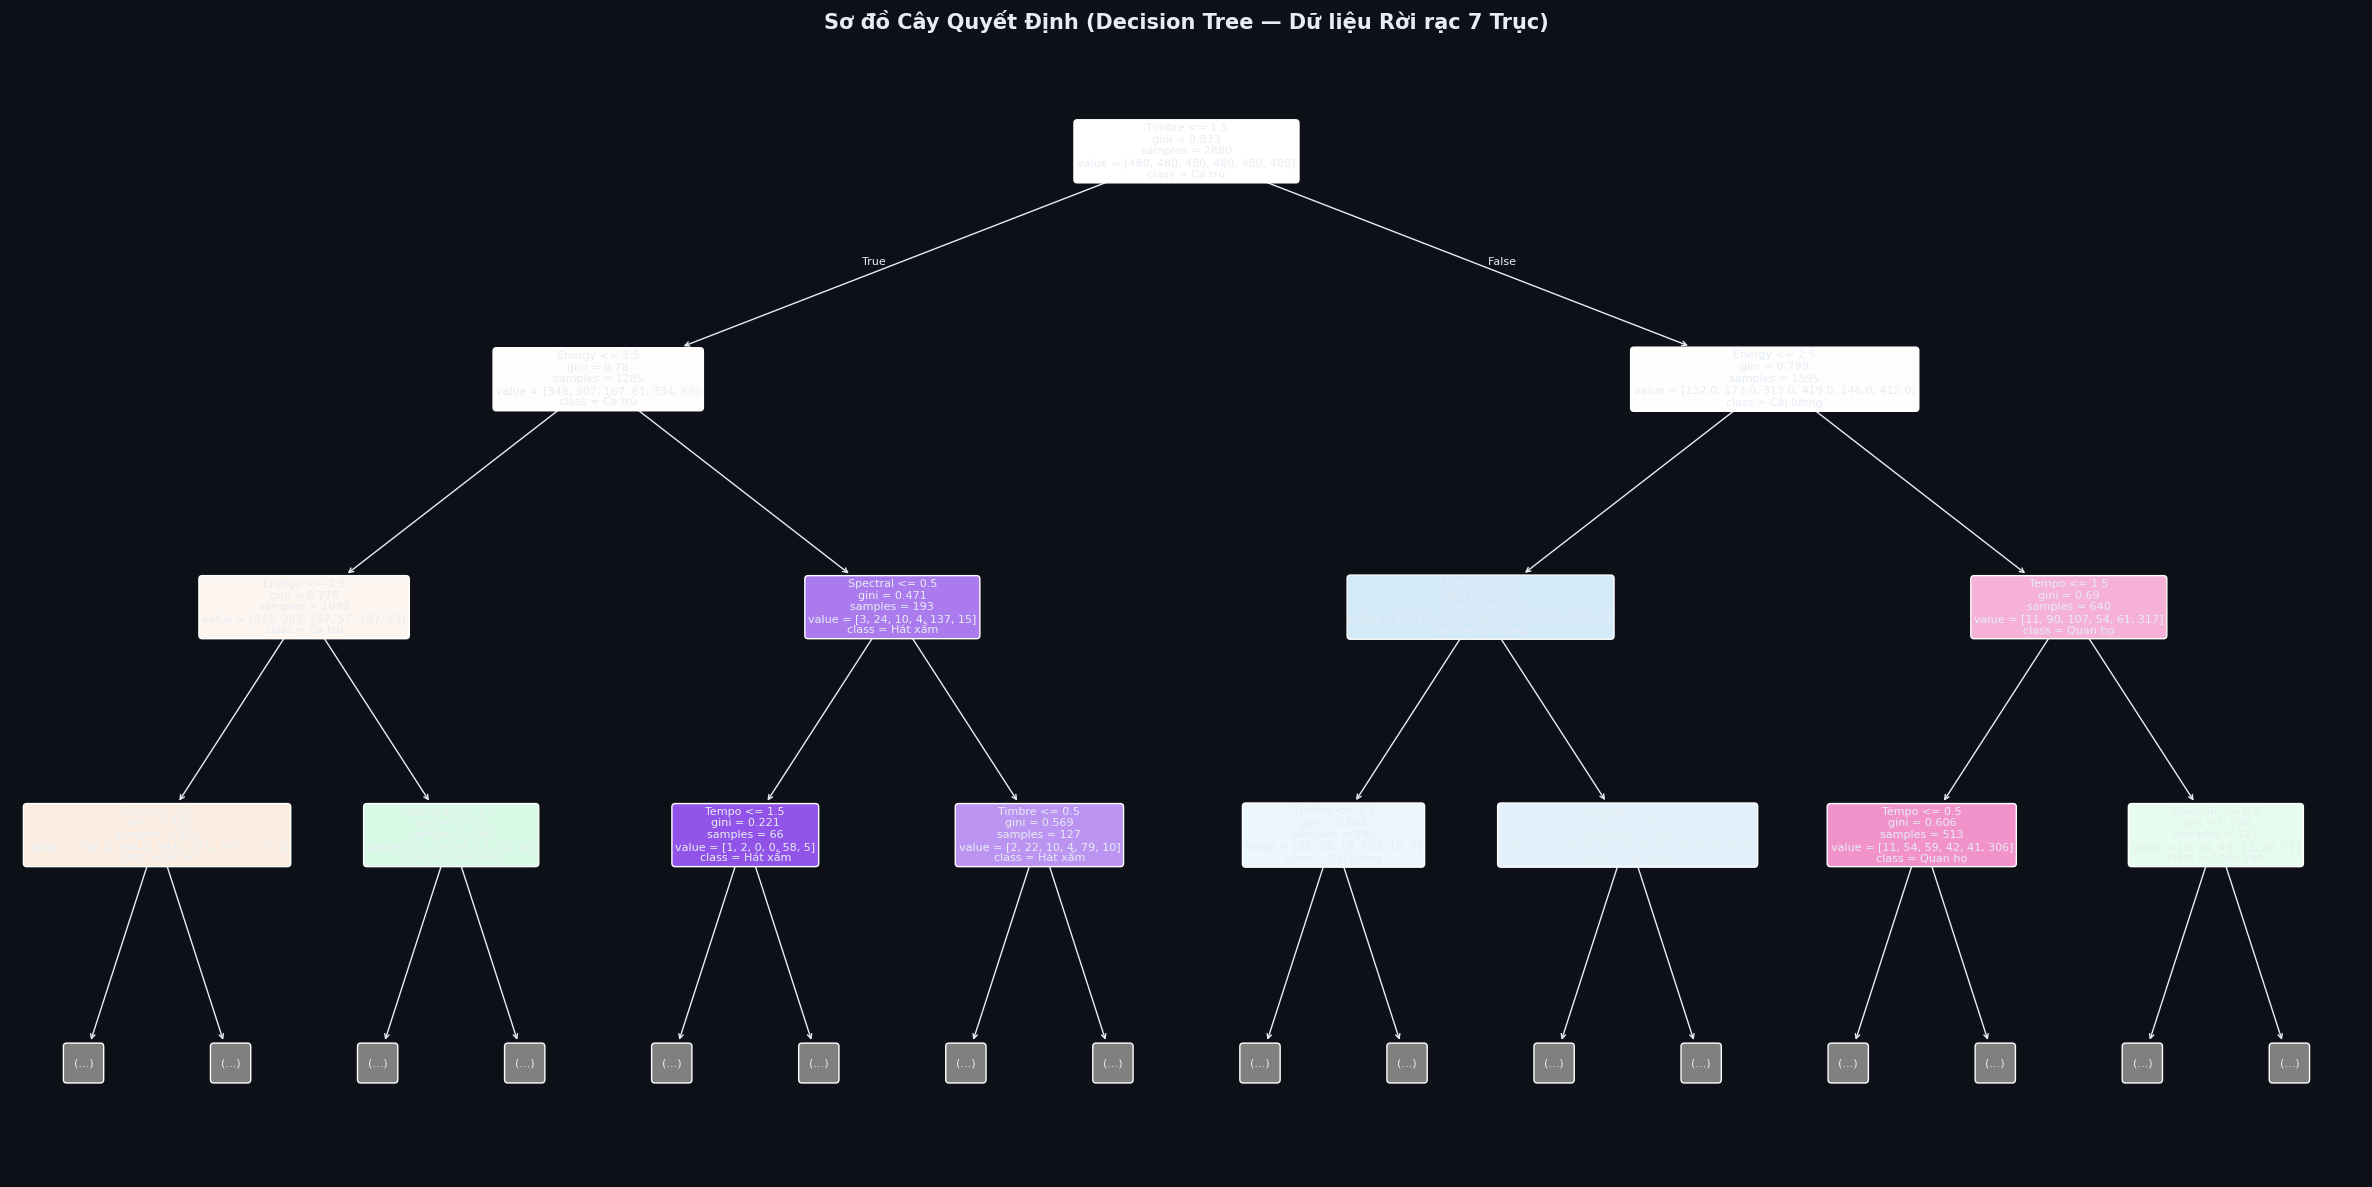

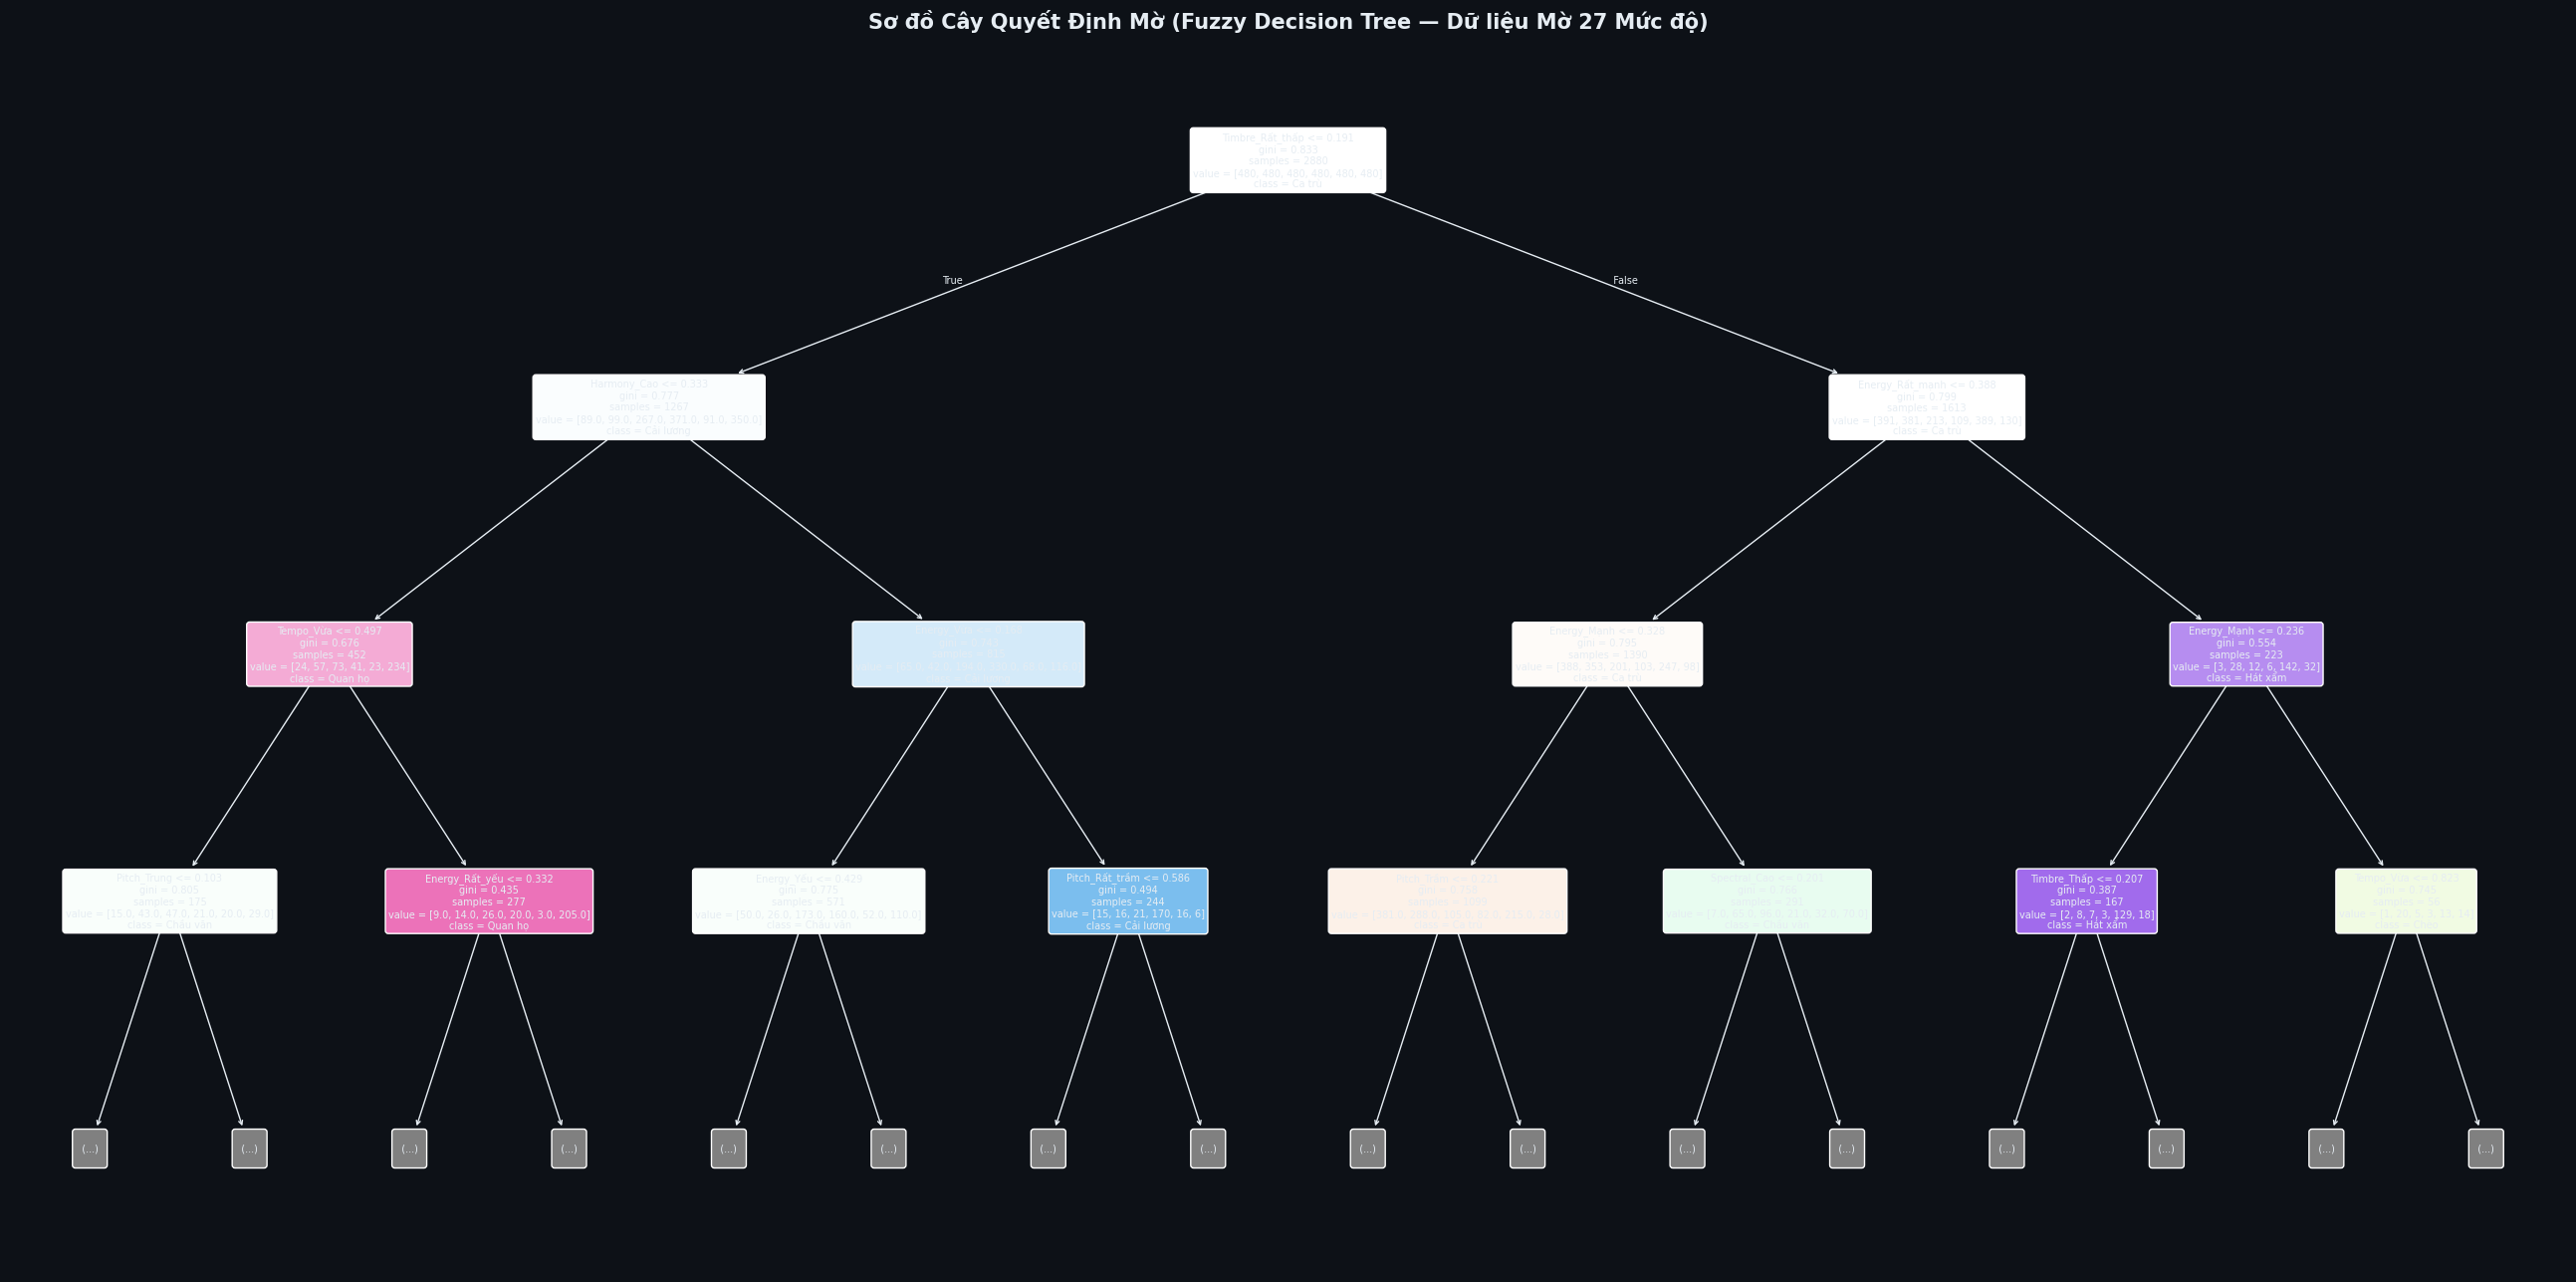

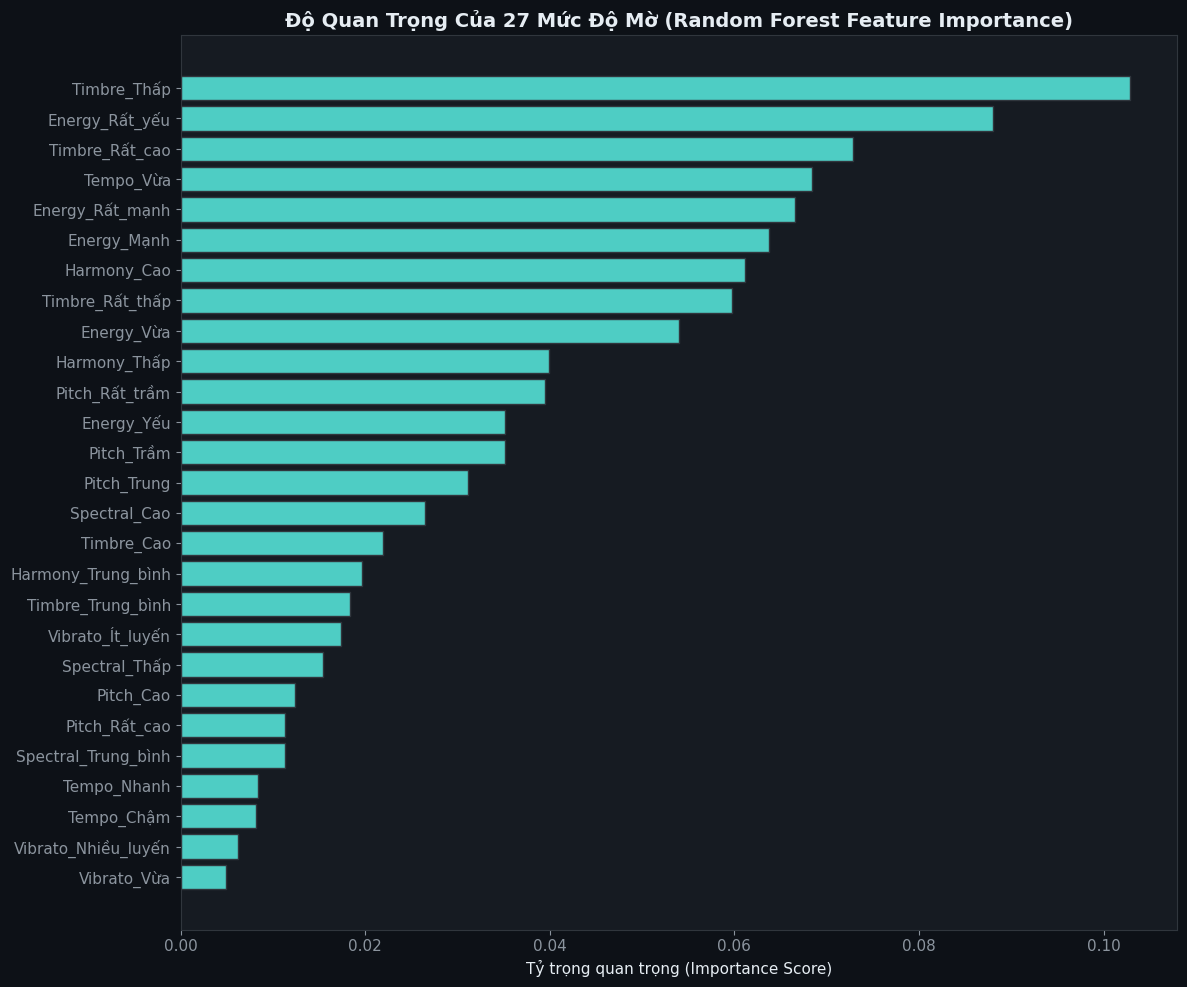

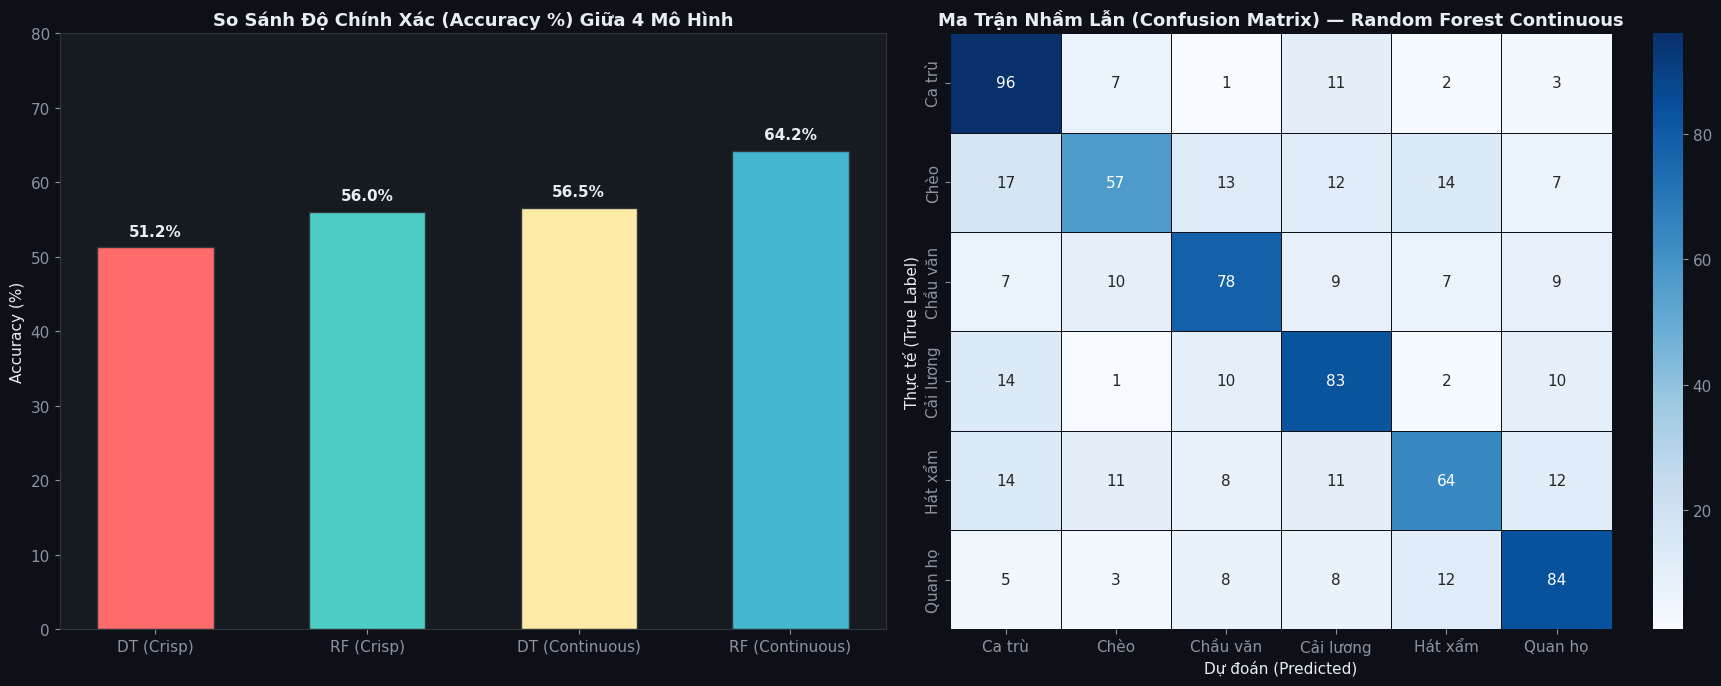

In [10]:
# 1. Sơ đồ cây Decision Tree Crisp 7 trục
plt.figure(figsize=(24, 12), facecolor='#0d1117')
plot_tree(dt_crisp, feature_names=crisp_feat_cols, class_names=class_names,
          filled=True, rounded=True, fontsize=8, max_depth=3)
plt.title('Sơ đồ Cây Quyết Định (Decision Tree — Dữ liệu Rời rạc 7 Trục)', fontsize=15, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('./data/plots/09_decision_tree_crisp_graph.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# 2. Sơ đồ cây Decision Tree Continuous 27 mức mờ
plt.figure(figsize=(26, 13), facecolor='#0d1117')
plot_tree(dt_cont, feature_names=cont_feat_cols, class_names=class_names,
          filled=True, rounded=True, fontsize=7, max_depth=3)
plt.title('Sơ đồ Cây Quyết Định Mờ (Fuzzy Decision Tree — Dữ liệu Mờ 27 Mức độ)', fontsize=15, fontweight='bold', color='#e6edf3')
plt.tight_layout()
plt.savefig('./data/plots/10_decision_tree_continuous_graph.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# 3. Random Forest Feature Importance (Continuous 27 mức độ mờ)
fi_df = pd.DataFrame({'Feature': cont_feat_cols, 'Importance': rf_cont.feature_importances_})
fi_df = fi_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(12, 10), facecolor='#0d1117')
plt.barh(fi_df['Feature'], fi_df['Importance'], color='#4ECDC4', edgecolor='#30363d')
plt.title('Độ Quan Trọng Của 27 Mức Độ Mờ (Random Forest Feature Importance)', fontsize=14, fontweight='bold', color='#e6edf3')
plt.xlabel('Tỷ trọng quan trọng (Importance Score)', fontsize=11)
plt.tight_layout()
plt.savefig('./data/plots/11_rf_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# 4. So sánh hiệu năng 4 mô hình & Confusion Matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7), facecolor='#0d1117')

models = ['DT (Crisp)', 'RF (Crisp)', 'DT (Continuous)', 'RF (Continuous)']
accuracies = [acc_dt_c * 100, acc_rf_c * 100, acc_dt_cnt * 100, acc_rf_cnt * 100]
colors = ['#FF6B6B', '#4ECDC4', '#FFEAA7', '#45B7D1']

bars = ax1.bar(models, accuracies, color=colors, edgecolor='#30363d', width=0.55)
ax1.set_ylim(0, 80)
ax1.set_title('So Sánh Độ Chính Xác (Accuracy %) Giữa 4 Mô Hình', fontsize=13, fontweight='bold')
ax1.set_ylabel('Accuracy (%)', fontsize=11)
for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., h + 1.2, f'{h:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

cm = confusion_matrix(y_cnt_test, pred_rf_cnt, labels=class_names)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
            ax=ax2, linecolor='#0d1117', linewidths=0.5)
ax2.set_title('Ma Trận Nhầm Lẫn (Confusion Matrix) — Random Forest Continuous', fontsize=13, fontweight='bold')
ax2.set_xlabel('Dự đoán (Predicted)', fontsize=11)
ax2.set_ylabel('Thực tế (True Label)', fontsize=11)

plt.tight_layout()
plt.savefig('./data/plots/12_model_performance_comparison.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()